# Taufactor tortuosity workflow

This notebook keeps three ideas separate:

1. Load and validate the segmentation.
2. Standardise labels so pore is `0` and active material is `1`.
3. Build the in-memory conductive mask that `taufactor` needs and solve tortuosity.

`taufactor` treats voxels labelled `1` as the conductive phase. If the transport phase is pore, this notebook creates a temporary mask where pore voxels are `1` without writing an inverted TIFF file.

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import taufactor as tau
import tifffile
from tabulate import tabulate

try:
    from taufactor.utils import flux_direction
except ImportError:
    flux_direction = None

try:
    from scipy import ndimage
except ImportError:
    ndimage = None

try:
    from skimage.feature import peak_local_max
    from skimage.segmentation import watershed
except ImportError:
    peak_local_max = None
    watershed = None

## Configuration

Set `RAW_PORE_LABEL` manually if you know which value in the TIFF represents pore. If you do not know it, use the visual check below or set `EXPECTED_POROSITY` and let the notebook choose the raw label whose volume fraction is closest to that porosity.

In [29]:
IMAGE_PATH = Path(r"C:\PhD_programs\Confirmation_Review_data\NREL_Data\Sample_1\GroundTruth_Extracted_Data\nmc-1-cal-expectedporsoity.tif")
DATA_NAME = "NREL-NMC-1-CAL"

# If the raw TIFF already uses pore=0 and active material=1, leave this as 0.
# If the raw TIFF uses pore=1 and active material=0, set this to 1.
# If you want inference from a known porosity, set this to None and set EXPECTED_POROSITY.
RAW_PORE_LABEL = 0
EXPECTED_POROSITY = None  # Example: 0.35

# taufactor needs the conductive phase to be 1.
# Use "pore" for pore tortuosity or "active" for active-material tortuosity.
TRANSPORT_PHASE = "pore"

# Use "all", "x", "y", or "z".
FLUX_DIRECTION = "all"

# Voxel spacing along image axes (axis 0, axis 1, axis 2), in any consistent length unit.
# Leave as (1, 1, 1) for voxel-normalised specific surface area.
# Example: (50e-9, 50e-9, 50e-9) gives specific surface area in m^-1.
VOXEL_SIZE = (398e-9, 398e-9, 398e-9)

# Particle size distribution settings.
PARTICLE_PHASE = "active"
PARTICLE_SEPARATION_METHOD = "watershed"  # "connected" or "watershed"
PARTICLE_CONNECTIVITY = 1  # 1=face-connected, 2=edge-connected, 3=corner-connected
MIN_PARTICLE_VOXELS = 1
PSD_BINS = 20

# Watershed settings. Increase WATERSHED_MIN_DISTANCE to reduce over-segmentation.
WATERSHED_MIN_DISTANCE = 3
WATERSHED_SMOOTH_SIGMA = 0.0
WATERSHED_COMPACTNESS = 0.0

## Small Utilities

In [30]:
def as_scalar(value):
    """Convert numpy/tensor scalars to regular Python scalars for printing."""
    return value.item() if hasattr(value, "item") else value


def load_tiff(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find TIFF file: {path}")
    return tifffile.imread(path)


def label_summary(img):
    values, counts = np.unique(img, return_counts=True)
    total = img.size
    return [
        {
            "label": as_scalar(value),
            "count": int(count),
            "fraction": float(count / total),
        }
        for value, count in zip(values, counts)
    ]


def print_image_summary(name, img):
    print(f"{name}: shape={img.shape}, dtype={img.dtype}, ndim={img.ndim}")
    print(tabulate(label_summary(img), headers="keys", tablefmt="grid", floatfmt=".6f"))

## Label Standardisation

The canonical segmentation used in this notebook is always:

- `0`: pore
- `1`: active material

A binary segmented image does not intrinsically know which label means pore, so either set `RAW_PORE_LABEL` from prior knowledge/visual inspection, or provide `EXPECTED_POROSITY`.

In [31]:
def standardise_binary_segmentation(raw, pore_label_in_raw=None, expected_porosity=None):
    """Return a uint8 segmentation where pore=0 and active material=1."""
    values, counts = np.unique(raw, return_counts=True)

    if values.size != 2:
        raise ValueError(
            f"Expected exactly 2 labels in the segmentation, but found {values.size}: {values}"
        )

    fractions = counts / counts.sum()

    if pore_label_in_raw is None:
        if expected_porosity is None:
            raise ValueError(
                "Raw labels are arbitrary. Set pore_label_in_raw from inspection, "
                "or set expected_porosity so the pore label can be inferred."
            )
        if not 0 <= expected_porosity <= 1:
            raise ValueError("expected_porosity must be between 0 and 1.")
        pore_index = int(np.argmin(np.abs(fractions - expected_porosity)))
        pore_label_in_raw = values[pore_index]
    else:
        matches = np.flatnonzero(values == pore_label_in_raw)
        if matches.size == 0:
            raise ValueError(
                f"pore_label_in_raw={pore_label_in_raw} is not present in the image. "
                f"Available labels are {values}."
            )
        pore_label_in_raw = values[int(matches[0])]

    active_values = values[values != pore_label_in_raw]
    if active_values.size != 1:
        raise ValueError("Could not identify a single active-material label.")

    active_label_in_raw = active_values[0]
    segmentation = np.where(raw == pore_label_in_raw, 0, 1).astype(np.uint8)

    info = {
        "raw_pore_label": as_scalar(pore_label_in_raw),
        "raw_active_label": as_scalar(active_label_in_raw),
        "porosity": float(np.mean(segmentation == 0)),
        "active_fraction": float(np.mean(segmentation == 1)),
    }
    return segmentation, info

## Taufactor Preparation and Solver

`taufactor` expects the conductive phase to be `1`. The canonical segmentation remains `pore=0, active=1`; the conductive mask is a separate temporary array.

Specific surface area is estimated by face counting: pore-active interface area divided by total image volume. With `VOXEL_SIZE = (1, 1, 1)`, the units are voxel^-1.

In [32]:
def phase_label_for_transport(transport_phase):
    """Return the canonical label for a named transport phase."""
    phase_to_label = {
        "pore": 0,
        "active": 1,
        "active_material": 1,
    }
    transport_phase = transport_phase.lower()
    if transport_phase not in phase_to_label:
        raise ValueError(f"transport_phase must be one of {sorted(phase_to_label)}.")
    return phase_to_label[transport_phase]


def validate_canonical_segmentation(segmentation):
    labels = np.unique(segmentation)
    if not np.array_equal(labels, np.array([0, 1], dtype=segmentation.dtype)):
        raise ValueError(f"Expected canonical labels [0, 1], but found {labels}.")


def make_conductive_mask(segmentation, transport_phase):
    """Create a taufactor-ready mask with the chosen transport phase set to 1."""
    validate_canonical_segmentation(segmentation)

    conductive_label = phase_label_for_transport(transport_phase)
    return (segmentation == conductive_label).astype(np.uint8)


def normalise_voxel_size(voxel_size):
    voxel_size = np.asarray(voxel_size, dtype=float)
    if voxel_size.size == 1:
        voxel_size = np.repeat(voxel_size, 3)
    if voxel_size.shape != (3,):
        raise ValueError("voxel_size must be a scalar or a 3-item sequence.")
    if np.any(voxel_size <= 0):
        raise ValueError("voxel_size values must be positive.")
    return voxel_size


def calculate_morphology_metrics(segmentation, transport_phase, voxel_size=(1.0, 1.0, 1.0)):
    """Calculate phase fraction and pore-active specific surface area."""
    validate_canonical_segmentation(segmentation)
    if segmentation.ndim != 3:
        raise ValueError(f"Expected a 3D volume, but got shape {segmentation.shape}.")

    dz, dy, dx = normalise_voxel_size(voxel_size)
    transport_label = phase_label_for_transport(transport_phase)

    interface_area = 0.0
    interface_area += np.count_nonzero(segmentation[1:, :, :] != segmentation[:-1, :, :]) * dy * dx
    interface_area += np.count_nonzero(segmentation[:, 1:, :] != segmentation[:, :-1, :]) * dz * dx
    interface_area += np.count_nonzero(segmentation[:, :, 1:] != segmentation[:, :, :-1]) * dz * dy

    total_volume = segmentation.shape[0] * dz * segmentation.shape[1] * dy * segmentation.shape[2] * dx

    return {
        "phase_fraction": float(np.mean(segmentation == transport_label)),
        "specific_surface_area": float(interface_area / total_volume),
    }


def orient_for_flux_direction(mask, direction):
    """Match the axis permutations from the original script."""
    if mask.ndim != 3:
        raise ValueError(f"Expected a 3D volume, but got shape {mask.shape}.")

    direction = direction.lower()
    if direction == "y":
        oriented = mask
    elif direction == "x":
        oriented = np.transpose(mask, (1, 2, 0))
    elif direction == "z":
        oriented = np.transpose(mask, (2, 0, 1))
    else:
        raise ValueError("direction must be one of 'x', 'y', or 'z'.")

    return np.ascontiguousarray(oriented)


def calc_tortuosity(
    conductive_mask,
    data_name,
    flux_direction_request="all",
    transport_phase="pore",
    morphology_metrics=None,
):
    directions = ["y", "x", "z"] if flux_direction_request == "all" else [flux_direction_request]
    morphology_metrics = morphology_metrics or {}
    rows = []

    for direction in directions:
        img = orient_for_flux_direction(conductive_mask, direction)
        solver = tau.Solver(img)
        solver.solve()

        row = {
            "data": data_name,
            "transport_phase": transport_phase,
            "flux_direction": direction,
            "effective_diffusivity": float(as_scalar(solver.D_eff)),
            "tortuosity": float(as_scalar(solver.tau)),
        }
        row.update(morphology_metrics)
        rows.append(row)

    return rows


def print_tortuosity_results(rows):
    print(tabulate(rows, headers="keys", tablefmt="grid", floatfmt=".6f"))

## Visual Sanity Check

In [33]:
def show_middle_slices(volume, title=None):
    if volume.ndim != 3:
        raise ValueError(f"Expected a 3D volume, but got shape {volume.shape}.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axis_names = ["axis 0", "axis 1", "axis 2"]

    for axis, ax in enumerate(axes):
        index = volume.shape[axis] // 2
        img_2d = np.take(volume, index, axis=axis)
        ax.imshow(img_2d, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{axis_names[axis]} slice {index}")
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

## Particle Size Distribution Utilities

Particle size distribution can be calculated from connected components or with distance-transform watershed separation. Watershed places markers at local maxima of the particle distance map, then splits touching particles along narrow necks.

Watershed separation requires `scipy` and `scikit-image` in the notebook environment.

In [ ]:
def connectivity_structure(connectivity):
    if ndimage is None:
        raise ImportError("scipy is required for connected-component particle sizing.")
    if connectivity not in (1, 2, 3):
        raise ValueError("connectivity must be 1, 2, or 3.")
    return ndimage.generate_binary_structure(rank=3, connectivity=connectivity)


def make_particle_mask(segmentation, particle_phase="active"):
    validate_canonical_segmentation(segmentation)
    if segmentation.ndim != 3:
        raise ValueError(f"Expected a 3D volume, but got shape {segmentation.shape}.")
    particle_label = phase_label_for_transport(particle_phase)
    return segmentation == particle_label


def label_connected_particles(particle_mask, connectivity=1):
    """Label connected regions without splitting touching particles."""
    return ndimage.label(particle_mask, structure=connectivity_structure(connectivity))[0]


def require_watershed_dependencies():
    if ndimage is None:
        raise ImportError("scipy is required for watershed particle separation.")
    if peak_local_max is None or watershed is None:
        raise ImportError("scikit-image is required for watershed particle separation.")


def label_watershed_particles(
    particle_mask,
    voxel_size=(1.0, 1.0, 1.0),
    connectivity=1,
    min_distance=3,
    smooth_sigma=0.0,
    compactness=0.0,
):
    """Split touching particles with distance-transform watershed."""
    require_watershed_dependencies()
    voxel_size = normalise_voxel_size(voxel_size)
    connected_labels, connected_count = ndimage.label(
        particle_mask,
        structure=connectivity_structure(connectivity),
    )
    if connected_count == 0:
        return connected_labels

    distance = ndimage.distance_transform_edt(particle_mask, sampling=voxel_size)
    marker_distance = distance.copy()
    if smooth_sigma > 0:
        marker_distance = ndimage.gaussian_filter(marker_distance, sigma=smooth_sigma)

    peak_coords = peak_local_max(
        marker_distance,
        labels=particle_mask,
        min_distance=min_distance,
        exclude_border=False,
    )

    markers = np.zeros(particle_mask.shape, dtype=np.int32)
    if peak_coords.size:
        markers[tuple(peak_coords.T)] = np.arange(1, len(peak_coords) + 1)

    # Make sure every connected region has at least one marker.
    next_marker = int(markers.max()) + 1
    for component_id in range(1, connected_count + 1):
        component_mask = connected_labels == component_id
        if np.any(markers[component_mask]):
            continue
        component_scores = np.where(component_mask, marker_distance, -np.inf)
        marker_index = np.unravel_index(np.argmax(component_scores), component_scores.shape)
        markers[marker_index] = next_marker
        next_marker += 1

    return watershed(
        -distance,
        markers=markers,
        mask=particle_mask,
        compactness=compactness,
    )


def separate_particles(
    segmentation,
    particle_phase="active",
    method="watershed",
    voxel_size=(1.0, 1.0, 1.0),
    connectivity=1,
    watershed_min_distance=3,
    watershed_smooth_sigma=0.0,
    watershed_compactness=0.0,
):
    particle_mask = make_particle_mask(segmentation, particle_phase)
    method = method.lower()
    if method == "connected":
        return label_connected_particles(particle_mask, connectivity=connectivity)
    if method == "watershed":
        return label_watershed_particles(
            particle_mask,
            voxel_size=voxel_size,
            connectivity=connectivity,
            min_distance=watershed_min_distance,
            smooth_sigma=watershed_smooth_sigma,
            compactness=watershed_compactness,
        )
    raise ValueError("method must be 'connected' or 'watershed'.")


def measure_particle_labels(labelled_particles, voxel_size=(1.0, 1.0, 1.0), min_voxels=1):
    if min_voxels < 1:
        raise ValueError("min_voxels must be at least 1.")

    voxel_size = normalise_voxel_size(voxel_size)
    voxel_volume = float(np.prod(voxel_size))
    particle_count = int(labelled_particles.max())
    if particle_count == 0:
        return []

    voxel_counts = np.bincount(labelled_particles.ravel())[1:]
    particle_ids = np.arange(1, particle_count + 1)
    keep = voxel_counts >= min_voxels

    particle_ids = particle_ids[keep]
    voxel_counts = voxel_counts[keep]
    volumes = voxel_counts * voxel_volume
    equivalent_diameters = np.cbrt(6.0 * volumes / np.pi)

    return [
        {
            "particle_id": int(particle_id),
            "voxel_count": int(voxel_count),
            "volume": float(volume),
            "equivalent_spherical_diameter": float(diameter),
        }
        for particle_id, voxel_count, volume, diameter in zip(
            particle_ids,
            voxel_counts,
            volumes,
            equivalent_diameters,
        )
    ]


def calculate_particle_size_distribution(
    segmentation,
    particle_phase="active",
    voxel_size=(1.0, 1.0, 1.0),
    connectivity=1,
    min_voxels=1,
    separation_method="watershed",
    watershed_min_distance=3,
    watershed_smooth_sigma=0.0,
    watershed_compactness=0.0,
    return_labels=False,
):
    """Separate particles and return equivalent spherical diameters."""
    labelled_particles = separate_particles(
        segmentation,
        particle_phase=particle_phase,
        method=separation_method,
        voxel_size=voxel_size,
        connectivity=connectivity,
        watershed_min_distance=watershed_min_distance,
        watershed_smooth_sigma=watershed_smooth_sigma,
        watershed_compactness=watershed_compactness,
    )
    particles = measure_particle_labels(labelled_particles, voxel_size=voxel_size, min_voxels=min_voxels)
    if return_labels:
        return particles, labelled_particles
    return particles


def summarize_particle_size_distribution(particles):
    if not particles:
        return {
            "particle_count": 0,
            "mean_equivalent_diameter": np.nan,
            "median_equivalent_diameter": np.nan,
            "d10": np.nan,
            "d50": np.nan,
            "d90": np.nan,
            "volume_weighted_mean_diameter": np.nan,
            "largest_particle_diameter": np.nan,
            "total_particle_volume": 0.0,
        }

    diameters = np.array([row["equivalent_spherical_diameter"] for row in particles])
    volumes = np.array([row["volume"] for row in particles])

    return {
        "particle_count": int(len(particles)),
        "mean_equivalent_diameter": float(np.mean(diameters)),
        "median_equivalent_diameter": float(np.median(diameters)),
        "d10": float(np.percentile(diameters, 10)),
        "d50": float(np.percentile(diameters, 50)),
        "d90": float(np.percentile(diameters, 90)),
        "volume_weighted_mean_diameter": float(np.average(diameters, weights=volumes)),
        "largest_particle_diameter": float(np.max(diameters)),
        "total_particle_volume": float(np.sum(volumes)),
    }


def bin_particle_size_distribution(particles, bins=20):
    if not particles:
        return []

    diameters = np.array([row["equivalent_spherical_diameter"] for row in particles])
    volumes = np.array([row["volume"] for row in particles])
    counts, edges = np.histogram(diameters, bins=bins)
    volume_by_bin, _ = np.histogram(diameters, bins=edges, weights=volumes)
    total_volume = np.sum(volumes)

    return [
        {
            "diameter_min": float(edges[i]),
            "diameter_max": float(edges[i + 1]),
            "particle_count": int(counts[i]),
            "volume_fraction": float(volume_by_bin[i] / total_volume),
        }
        for i in range(len(counts))
    ]


def plot_particle_size_distribution(particles, bins=20, weight_by_volume=False):
    if not particles:
        print("No particles found for the selected phase.")
        return

    diameters = np.array([row["equivalent_spherical_diameter"] for row in particles])
    volumes = np.array([row["volume"] for row in particles])
    weights = volumes / np.sum(volumes) if weight_by_volume else None

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.hist(diameters, bins=bins, weights=weights, edgecolor="black")
    ax.set_xlabel("Equivalent spherical diameter")
    ax.set_ylabel("Volume fraction" if weight_by_volume else "Particle count")
    ax.set_title("Particle size distribution")
    plt.show()


def show_labelled_particle_slices(labelled_particles, title=None):
    if labelled_particles.ndim != 3:
        raise ValueError(f"Expected a 3D volume, but got shape {labelled_particles.shape}.")

    masked = np.ma.masked_where(labelled_particles == 0, labelled_particles)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axis_names = ["axis 0", "axis 1", "axis 2"]

    for axis, ax in enumerate(axes):
        index = labelled_particles.shape[axis] // 2
        img_2d = np.take(masked, index, axis=axis)
        ax.imshow(img_2d, cmap="nipy_spectral")
        ax.set_title(f"{axis_names[axis]} slice {index}")
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

## Load and Inspect the TIFF

In [46]:
img_raw = load_tiff(IMAGE_PATH)
print_image_summary("Raw TIFF", img_raw)

Raw TIFF: shape=(256, 600, 604), dtype=uint8, ndim=3
+---------+----------+------------+
|   label |    count |   fraction |
+=========+==========+============+
|       0 | 34143807 |   0.368030 |
+---------+----------+------------+
|       1 | 58630593 |   0.631970 |
+---------+----------+------------+


## Standardise to Pore=0 and Active Material=1

In [47]:
segmentation, label_info = standardise_binary_segmentation(
    img_raw,
    pore_label_in_raw=RAW_PORE_LABEL,
    expected_porosity=EXPECTED_POROSITY,
)

print("Raw-to-canonical label mapping:")
print(tabulate([label_info], headers="keys", tablefmt="grid", floatfmt=".6f"))
print()
print_image_summary("Canonical segmentation", segmentation)

Raw-to-canonical label mapping:
+------------------+--------------------+------------+-------------------+
|   raw_pore_label |   raw_active_label |   porosity |   active_fraction |
+==================+====================+============+===================+
|                0 |                  1 |   0.368030 |          0.631970 |
+------------------+--------------------+------------+-------------------+

Canonical segmentation: shape=(256, 600, 604), dtype=uint8, ndim=3
+---------+----------+------------+
|   label |    count |   fraction |
+=========+==========+============+
|       0 | 34143807 |   0.368030 |
+---------+----------+------------+
|       1 | 58630593 |   0.631970 |
+---------+----------+------------+


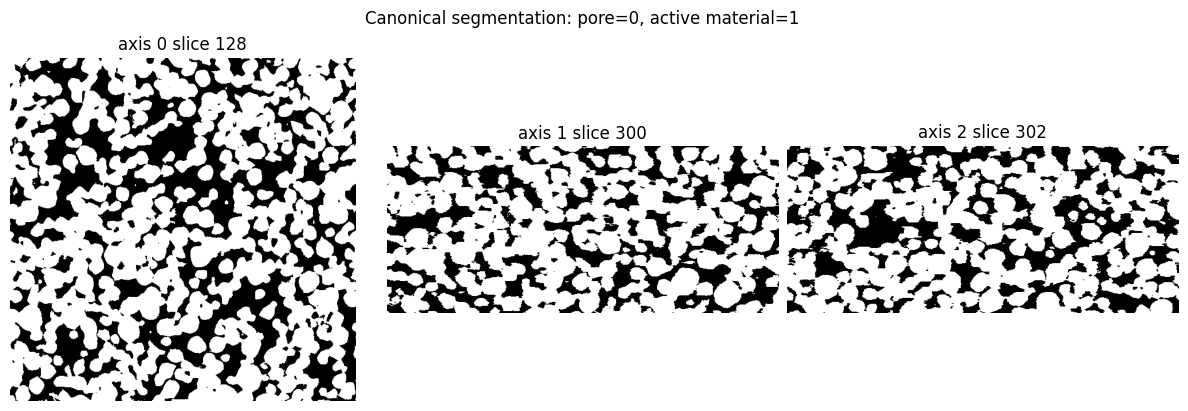

In [48]:
show_middle_slices(segmentation, "Canonical segmentation: pore=0, active material=1")

## Calculate Particle Size Distribution

This section calculates a particle size distribution for `PARTICLE_PHASE`. Use `PARTICLE_SEPARATION_METHOD = "watershed"` to split touching particles, or `"connected"` to treat each connected region as one particle.

Particle size summary for active phase using watershed separation:
+------------------+----------------------------+------------------------------+----------+----------+----------+---------------------------------+-----------------------------+-------------------------+---------------------+
|   particle_count |   mean_equivalent_diameter |   median_equivalent_diameter |      d10 |      d50 |      d90 |   volume_weighted_mean_diameter |   largest_particle_diameter |   total_particle_volume | separation_method   |
+==================+============================+==============================+==========+==========+==========+=================================+=============================+=========================+=====================+
|            12887 |                   0.000006 |                     0.000006 | 0.000000 | 0.000006 | 0.000011 |                        0.000011 |                    0.000019 |                0.000000 | watershed           |
+------------------+---------

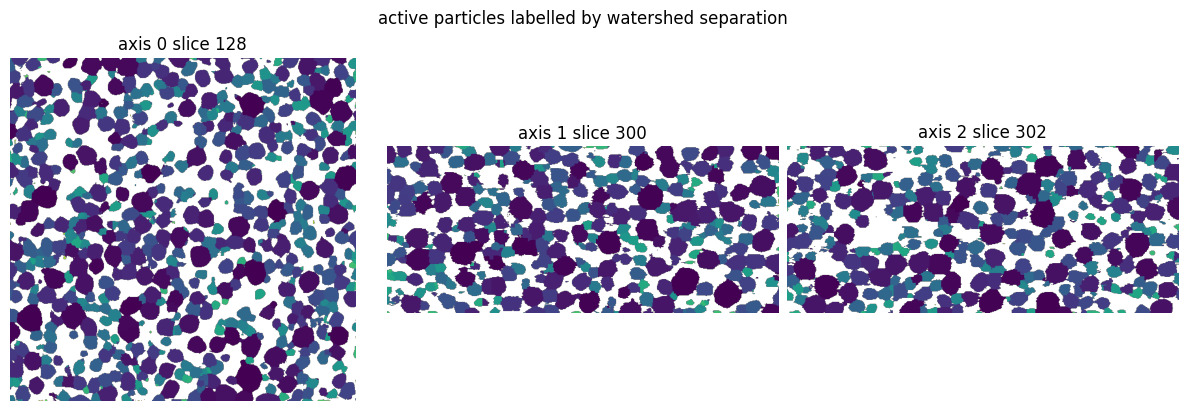


Particle size distribution (20 bins):
+----------------+----------------+------------------+-------------------+
|   diameter_min |   diameter_max |   particle_count |   volume_fraction |
+================+================+==================+===================+
|       0.000000 |       0.000001 |             3564 |          0.000293 |
+----------------+----------------+------------------+-------------------+
|       0.000001 |       0.000002 |              648 |          0.000560 |
+----------------+----------------+------------------+-------------------+
|       0.000002 |       0.000003 |              385 |          0.001176 |
+----------------+----------------+------------------+-------------------+
|       0.000003 |       0.000004 |              424 |          0.003000 |
+----------------+----------------+------------------+-------------------+
|       0.000004 |       0.000005 |              418 |          0.005816 |
+----------------+----------------+------------------+-------

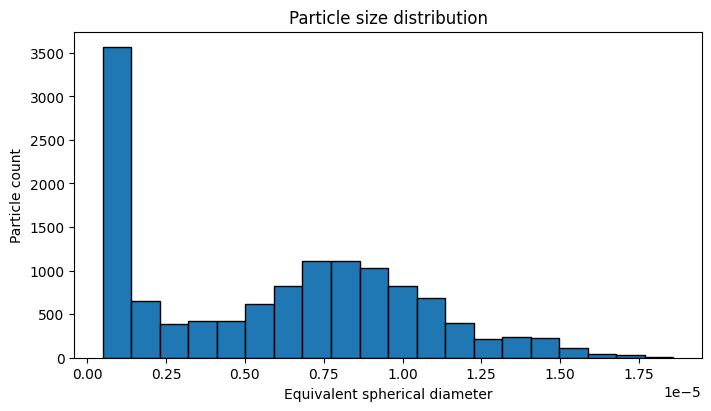

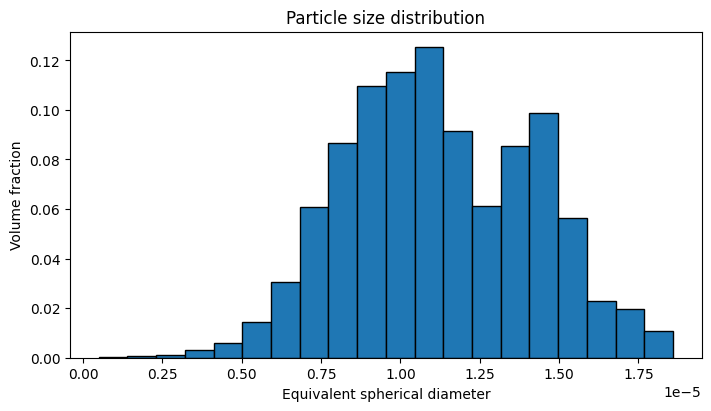

In [49]:
particle_sizes, labelled_particles = calculate_particle_size_distribution(
    segmentation,
    particle_phase=PARTICLE_PHASE,
    voxel_size=VOXEL_SIZE,
    connectivity=PARTICLE_CONNECTIVITY,
    min_voxels=MIN_PARTICLE_VOXELS,
    separation_method=PARTICLE_SEPARATION_METHOD,
    watershed_min_distance=WATERSHED_MIN_DISTANCE,
    watershed_smooth_sigma=WATERSHED_SMOOTH_SIGMA,
    watershed_compactness=WATERSHED_COMPACTNESS,
    return_labels=True,
)
particle_summary = summarize_particle_size_distribution(particle_sizes)
particle_summary["separation_method"] = PARTICLE_SEPARATION_METHOD
particle_histogram = bin_particle_size_distribution(particle_sizes, bins=PSD_BINS)
largest_particles = sorted(
    particle_sizes,
    key=lambda row: row["equivalent_spherical_diameter"],
    reverse=True,
)[:10]

print(f"Particle size summary for {PARTICLE_PHASE} phase using {PARTICLE_SEPARATION_METHOD} separation:")
print(tabulate([particle_summary], headers="keys", tablefmt="grid", floatfmt=".6f"))
print()
show_labelled_particle_slices(
    labelled_particles,
    f"{PARTICLE_PHASE} particles labelled by {PARTICLE_SEPARATION_METHOD} separation",
)
print()

if particle_histogram:
    print(f"Particle size distribution ({PSD_BINS} bins):")
    print(tabulate(particle_histogram, headers="keys", tablefmt="grid", floatfmt=".6f"))
    print()

    print("Largest particles:")
    print(tabulate(largest_particles, headers="keys", tablefmt="grid", floatfmt=".6f"))

    plot_particle_size_distribution(particle_sizes, bins=PSD_BINS, weight_by_volume=False)
    plot_particle_size_distribution(particle_sizes, bins=PSD_BINS, weight_by_volume=True)
else:
    print("No particles found for the selected phase.")

## Create the In-Memory Taufactor Mask

No inverted TIFF is saved here. If `TRANSPORT_PHASE = "pore"`, pore voxels are converted from canonical label `0` to conductive label `1` only in this temporary mask.

Taufactor conductive mask for pore transport: shape=(256, 600, 604), dtype=uint8, ndim=3
+---------+----------+------------+
|   label |    count |   fraction |
+=========+==========+============+
|       0 | 58630593 |   0.631970 |
+---------+----------+------------+
|       1 | 34143807 |   0.368030 |
+---------+----------+------------+

Morphology metrics:
+------------------+-------------------------+
|   phase_fraction |   specific_surface_area |
+==================+=========================+
|         0.368030 |           387518.203774 |
+------------------+-------------------------+


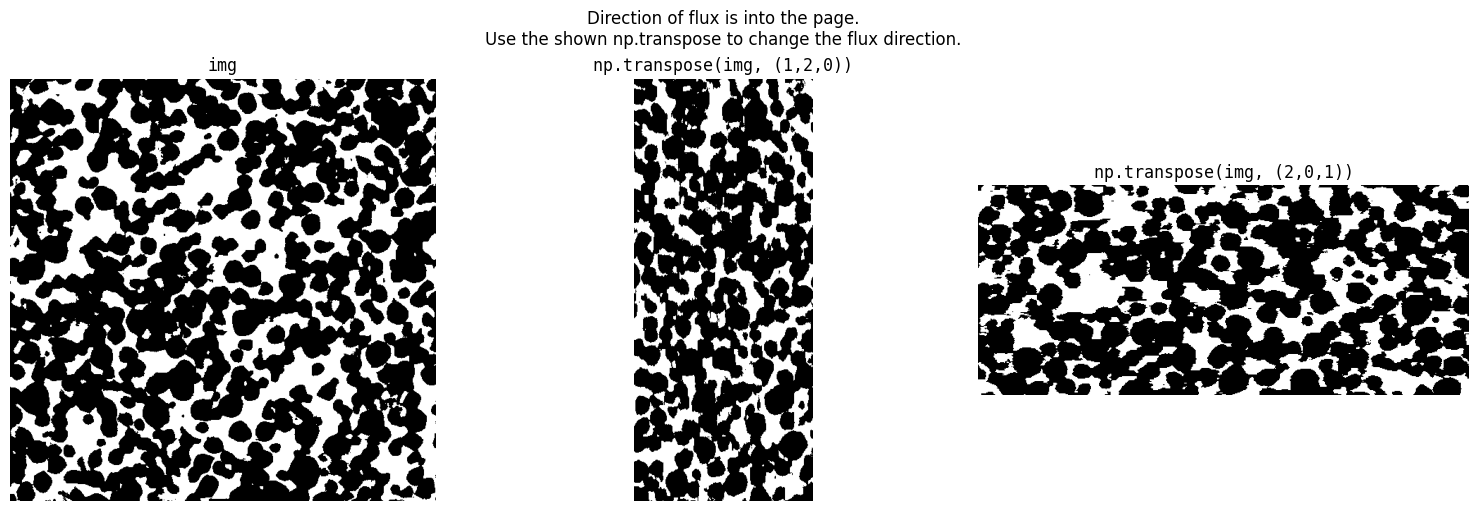

Flux direction diagnostic: (<Figure size 1500x500 with 3 Axes>, array([<Axes: title={'center': 'img'}>,
       <Axes: title={'center': 'np.transpose(img, (1,2,0))'}>,
       <Axes: title={'center': 'np.transpose(img, (2,0,1))'}>],
      dtype=object))


In [39]:
conductive_mask = make_conductive_mask(segmentation, TRANSPORT_PHASE)
morphology_metrics = calculate_morphology_metrics(segmentation, TRANSPORT_PHASE, VOXEL_SIZE)

print_image_summary(f"Taufactor conductive mask for {TRANSPORT_PHASE} transport", conductive_mask)
print()
print("Morphology metrics:")
print(tabulate([morphology_metrics], headers="keys", tablefmt="grid", floatfmt=".6f"))

if flux_direction is not None:
    try:
        print("Flux direction diagnostic:", flux_direction(conductive_mask))
    except Exception as exc:
        print(f"Flux direction diagnostic skipped: {exc}")

## Solve Tortuosity

In [40]:
results = calc_tortuosity(
    conductive_mask,
    DATA_NAME,
    flux_direction_request=FLUX_DIRECTION,
    transport_phase=TRANSPORT_PHASE,
    morphology_metrics=morphology_metrics,
)

print_tortuosity_results(results)

converged to: [2.8057096] after: 1000 iterations in: 41.3121s (0.0413 s/iter)
GPU-RAM currently 1868.46 MB (max allocated 2610.76 MB; 2625.63 MB reserved)
converged to: [2.0706742] after: 1800 iterations in: 73.9527s (0.0411 s/iter)
GPU-RAM currently 1868.37 MB (max allocated 2610.76 MB; 3380.61 MB reserved)
converged to: [2.0550733] after: 1900 iterations in: 77.7471s (0.0409 s/iter)
GPU-RAM currently 1868.46 MB (max allocated 2610.76 MB; 4135.58 MB reserved)
+----------------+-------------------+------------------+-------------------------+--------------+------------------+-------------------------+
| data           | transport_phase   | flux_direction   |   effective_diffusivity |   tortuosity |   phase_fraction |   specific_surface_area |
+================+===================+==================+=========================+==============+==================+=========================+
| NREL-NMC-1-CAL | pore              | y                |                0.131172 |     2.805710 |     